In [1]:
# IMPORTS
# no memo/jax -- world states are discrete, plain numpy throughout
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import exp

# GLOBALS -- world states (discrete 4-way, unlike whyask's continuous mu/theta)
CW, UW, CN, UN = 0, 1, 2, 3  # able+willing, able+unwilling, unable+willing, unable+unwilling
worlds = [CW, UW, CN, UN]
CAN, IMP = 0, 1               # no null -- ke formalism has exactly 2 utterances
utterances = [CAN, IMP]
ACTION, YES, DECLINE = 0, 1, 2
responses = [ACTION, YES, DECLINE]

# COSTS -- listener response costs (not speaker utterance costs like whyask)
c_a = 0.3          # physical action cost
c_v = 0.1          # verbal yes cost; c_a > c_v > c_d
c_d = 0.05         # decline cost
c_conflict = 0.5   # extra cost for declining imp (presupposition of ability violated)

# PRIORS -- speaker's beliefs about listener
p_able    = 0.8    # P(listener is able)
p_willing = 0.7    # P(listener is willing)
p_intent  = 0.5    # prior P(psi=request) for L1 intent inference

alpha = 5.0        # softmax rationality param (same role as whyask)
beta  = 1.0        # S1 conflict aversion weight -- new, no analogue in whyask

In [2]:
## L0 -- literal listener
# analogous to A0 in whyask, but full response dist over {action, yes, decline}
# key diff: L0 takes discrete world state w, not continuous (mu, theta)

w_label = {CW: 'cw', UW: 'uw', CN: 'cn', UN: 'un'}
u_label = {CAN: 'can', IMP: 'imp'}
r_label = {ACTION: 'action', YES: 'yes', DECLINE: 'decline'}

def truth(r, w, u):
    if r == ACTION:    return float(w == CW)                    # only able+willing can act
    elif r == YES:     return float(w == CW and u == CAN)       # yes only under can, only if cw
    elif r == DECLINE: return float(w != CW)                    # all non-cw states can decline
    return 0.0

def response_cost(r, u):
    # declining imp costs extra c_conflict -- violates presupposition of ability
    if r == ACTION:    return c_a
    elif r == YES:     return c_v
    elif r == DECLINE: return c_d + (c_conflict if u == IMP else 0.0)

def L0(u, w):
    # P(r | w, u) proportional to truth(r,w,u) * exp(-alpha * cost(r,u))
    probs = np.array([truth(r, w, u) * exp(-alpha * response_cost(r, u)) for r in responses])
    total = probs.sum()
    return probs / total if total > 0 else probs

for u in utterances:
    for w in worlds:
        probs = L0(u, w)
        print(f"L0(u={u_label[u]}, w={w_label[w]}) = { {r_label[r]: round(probs[r], 3) for r in responses} }")

L0(u=can, w=cw) = {'action': np.float64(0.269), 'yes': np.float64(0.731), 'decline': np.float64(0.0)}
L0(u=can, w=uw) = {'action': np.float64(0.0), 'yes': np.float64(0.0), 'decline': np.float64(1.0)}
L0(u=can, w=cn) = {'action': np.float64(0.0), 'yes': np.float64(0.0), 'decline': np.float64(1.0)}
L0(u=can, w=un) = {'action': np.float64(0.0), 'yes': np.float64(0.0), 'decline': np.float64(1.0)}
L0(u=imp, w=cw) = {'action': np.float64(1.0), 'yes': np.float64(0.0), 'decline': np.float64(0.0)}
L0(u=imp, w=uw) = {'action': np.float64(0.0), 'yes': np.float64(0.0), 'decline': np.float64(1.0)}
L0(u=imp, w=cn) = {'action': np.float64(0.0), 'yes': np.float64(0.0), 'decline': np.float64(1.0)}
L0(u=imp, w=un) = {'action': np.float64(0.0), 'yes': np.float64(0.0), 'decline': np.float64(1.0)}


In [3]:
## S1 -- pragmatic speaker
# key diff from whyask S1: no info/action goal split; speaker always wants action
# trades goal achievement (E[P(action)]) vs social cost of decline, weighted by beta

def world_prior(w, pa, pw):
    # factorizes bc ability and willingness are independent
    able    = float(w in [CW, UW])
    willing = float(w in [CW, CN])
    return (pa if able else 1 - pa) * (pw if willing else 1 - pw)

def goal_val(u, pa, pw):
    # E[P(action)] = P(w_cw) * L0(action | cw, u)
    return pa * pw * L0(u, CW)[ACTION]

def social_cost_val(u, pa, pw):
    # E[conflict cost] = P(non-compliant) * cost of decline under u
    p_nc = 1 - pa * pw
    conflict = c_d + (c_conflict if u == IMP else 0.0)
    return p_nc * conflict

def V_S1(u, pa, pw, b):
    # beta weights social cost -- new param relative to whyask
    return goal_val(u, pa, pw) - b * social_cost_val(u, pa, pw)

def S1(pa, pw, b=beta):
    vals = np.array([V_S1(u, pa, pw, b) for u in utterances])
    probs = np.exp(alpha * vals)
    return probs / probs.sum()

print("S1 utterance choice:")
for pw in [0.3, 0.5, 0.85]:
    out = S1(p_able, pw)
    print(f"  p_able={p_able}, p_willing={pw}: P(can)={out[CAN]:.3f}, P(imp)={out[IMP]:.3f}")

S1 utterance choice:
  p_able=0.8, p_willing=0.3: P(can)=0.736, P(imp)=0.264
  p_able=0.8, p_willing=0.5: P(can)=0.509, P(imp)=0.491
  p_able=0.8, p_willing=0.85: P(can)=0.156, P(imp)=0.844


In [4]:
## L1 -- pragmatic listener
# analogous to A1 in whyask, but infers speaker intent psi in {info, request}
# no S2/L2 in ke formalism -- only 3 levels deep (L0 -> S1 -> L1)

def intent_posterior(u, pa, pw, p_int=p_intent, b=beta):
    # P(psi | u) proportional to P(u | psi) * P(psi)
    # P(u | psi=request) = S1(u) -- requester uses full S1 tradeoff
    # P(u | psi=info) = 1 if u==CAN else 0 -- info-seeker never uses imp
    s1 = S1(pa, pw, b)
    p_u_req  = s1[u]
    p_u_info = 1.0 if u == CAN else 0.0

    p_req = p_int * p_u_req
    p_inf = (1 - p_int) * p_u_info
    total = p_req + p_inf
    if total == 0: return 0.5, 0.5
    return p_req / total, p_inf / total

def L1(u, w, pa, pw, p_int=p_intent, b=beta):
    # P(r | w, u) = sum_psi P(psi|u) * P(r | w, psi)
    p_req, p_inf = intent_posterior(u, pa, pw, p_int, b)
    probs = np.zeros(len(responses))
    if w == CW:
        probs[ACTION]  = p_req   # psi=request -> act
        probs[YES]     = p_inf   # psi=info -> yes
        probs[DECLINE] = 0.0
    else:
        probs[DECLINE] = 1.0     # non-cw always declines regardless of psi
    return probs

print("L1 (u=can, w=cw) -- P(action) scales w/ P(psi=request | can):")
for pw in [0.3, 0.5, 0.85]:
    out = L1(CAN, CW, p_able, pw)
    print(f"  p_willing={pw}: P(action)={out[ACTION]:.3f}, P(yes)={out[YES]:.3f}")

print("\nL1 (u=imp, w=cw) -- always acts (imp unambiguously signals request):")
for pw in [0.3, 0.5, 0.85]:
    out = L1(IMP, CW, p_able, pw)
    print(f"  p_willing={pw}: P(action)={out[ACTION]:.3f}, P(yes)={out[YES]:.3f}")

L1 (u=can, w=cw) -- P(action) scales w/ P(psi=request | can):
  p_willing=0.3: P(action)=0.424, P(yes)=0.576
  p_willing=0.5: P(action)=0.338, P(yes)=0.662
  p_willing=0.85: P(action)=0.135, P(yes)=0.865

L1 (u=imp, w=cw) -- always acts (imp unambiguously signals request):
  p_willing=0.3: P(action)=1.000, P(yes)=0.000
  p_willing=0.5: P(action)=1.000, P(yes)=0.000
  p_willing=0.85: P(action)=1.000, P(yes)=0.000


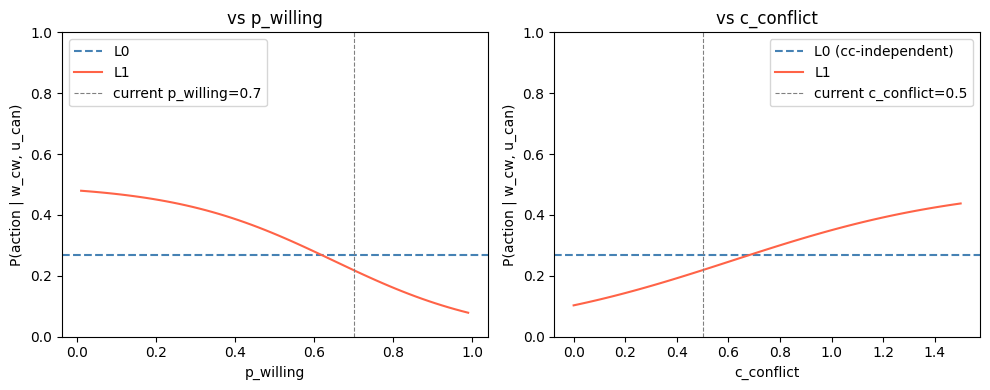

In [5]:
## plots: L0 vs L1
# analogous to A1 vs A2 plot in whyask
# L0 action prob is fixed by costs alone; L1 varies w/ context via intent inference

pw_vals = np.linspace(0.01, 0.99, 60)
cc_vals = np.linspace(0.0, 1.5, 60)

# helper: recompute L1 P(action | CW, CAN) with a different c_conflict
# L0(CAN, CW)[ACTION] doesn't depend on cc -- only decline cost changes
def l1_action_cc(pw, cc, pa=p_able, p_int=p_intent, b=beta):
    l0_can = L0(CAN, CW)[ACTION]   # constant -- cc doesn't affect action/yes costs
    l0_imp = L0(IMP, CW)[ACTION]   # = 1.0
    gv = lambda u: pa * pw * (l0_can if u == CAN else l0_imp)
    sc = lambda u: (1 - pa * pw) * (c_d + (cc if u == IMP else 0.0))
    sv = np.exp(alpha * np.array([gv(u) - b * sc(u) for u in utterances]))
    s1_ = sv / sv.sum()
    p_req = p_int * s1_[CAN]
    p_inf = (1 - p_int) * 1.0
    tot = p_req + p_inf
    return p_req / tot if tot > 0 else 0.5

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
l0_val = L0(CAN, CW)[ACTION]
ax.axhline(l0_val, label='L0', color='steelblue', linestyle='--')
l1v = [L1(CAN, CW, p_able, pw)[ACTION] for pw in pw_vals]
ax.plot(pw_vals, l1v, label='L1', color='tomato')
ax.axvline(p_willing, color='gray', linestyle='--', linewidth=.8, label=f'current p_willing={p_willing}')
ax.set_xlabel('p_willing')
ax.set_ylabel('P(action | w_cw, u_can)')
ax.set_title('vs p_willing')
ax.legend(); ax.set_ylim(0, 1)

ax = axes[1]
# higher c_conflict -> S1 over-uses can (imp too risky to decline) -> can less diagnostic -> L1 acts more
ax.axhline(l0_val, label='L0 (cc-independent)', color='steelblue', linestyle='--')
l1_cc = [l1_action_cc(p_willing, cc) for cc in cc_vals]
ax.plot(cc_vals, l1_cc, label='L1', color='tomato')
ax.axvline(c_conflict, color='gray', linestyle='--', linewidth=.8, label=f'current c_conflict={c_conflict}')
ax.set_xlabel('c_conflict')
ax.set_ylabel('P(action | w_cw, u_can)')
ax.set_title('vs c_conflict')
ax.legend(); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

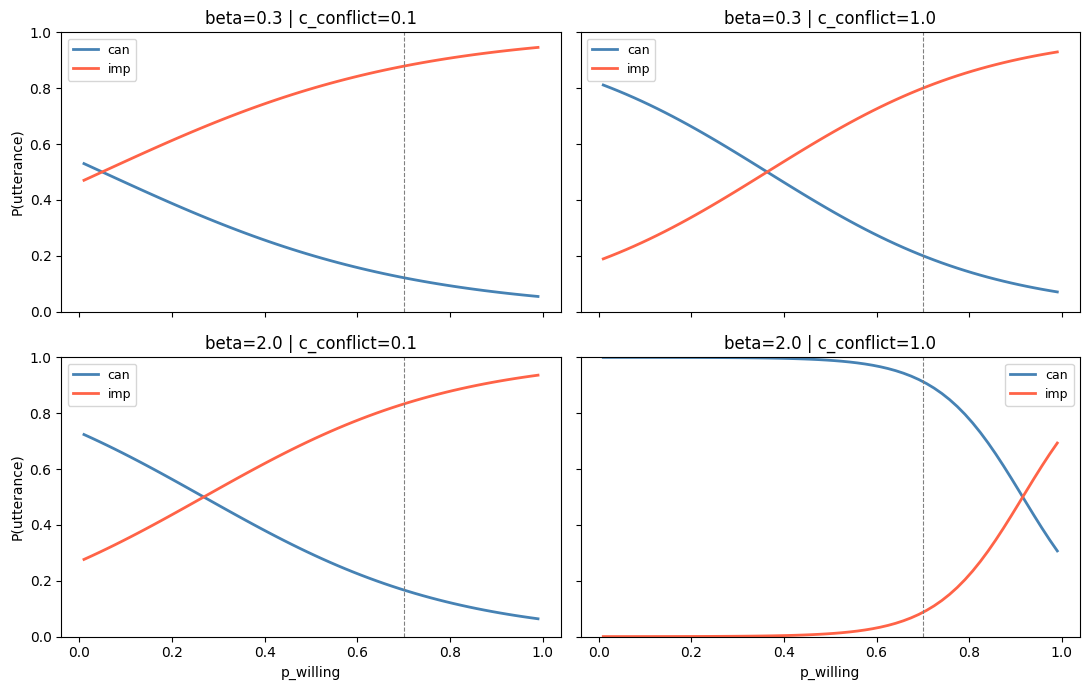

In [6]:
## plots: S1
# analogous to S1 vs S2 plot in whyask (no S2 here)
# 2x2: rows = beta lo/hi, cols = c_conflict lo/hi; x = p_willing
# shows how conflict aversion and conflict cost jointly shape utterance choice

pw_vals = np.linspace(0.01, 0.99, 60)
u_colors = {CAN: 'steelblue', IMP: 'tomato'}
u_labels_plot = {CAN: 'can', IMP: 'imp'}

beta_lo, beta_hi = 0.3, 2.0
cc_lo, cc_hi = 0.1, 1.0

# helper: S1 with custom beta and c_conflict
def s1_cc(pa, pw, b, cc):
    l0_can = L0(CAN, CW)[ACTION]
    l0_imp = L0(IMP, CW)[ACTION]
    gv = lambda u: pa * pw * (l0_can if u == CAN else l0_imp)
    sc = lambda u: (1 - pa * pw) * (c_d + (cc if u == IMP else 0.0))
    sv = np.exp(alpha * np.array([gv(u) - b * sc(u) for u in utterances]))
    return sv / sv.sum()

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)

for ri, b in enumerate([beta_lo, beta_hi]):
    for ci, cc in enumerate([cc_lo, cc_hi]):
        ax = axes[ri, ci]
        for ui in utterances:
            ax.plot(pw_vals, [s1_cc(p_able, pw, b, cc)[ui] for pw in pw_vals],
                    color=u_colors[ui], label=u_labels_plot[ui], linewidth=2)
        ax.set_title(f'beta={b} | c_conflict={cc}')
        ax.set_ylim(0, 1)
        if ri == 1: ax.set_xlabel('p_willing')
        if ci == 0: ax.set_ylabel('P(utterance)')
        ax.axvline(p_willing, color='gray', linestyle='--', linewidth=.8)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()